In [4]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [5]:
class Perceptron:

    def __init__(self, learning_rate=0.01, batch_size=64, max_iter=1500, random_state=42) -> None:

        self.lr = learning_rate
        self.batch_size = batch_size
        self.max_iter = max_iter
        self.coefs_ = None
        np.random.seed(random_state)
    

    def predict(self, X):

        m = X.shape[0]
        X = np.hstack((np.ones((m, 1)), X))
        return self.step(np.dot(X, self.coefs_))
    

    def batch_generator(self, X, y, batch_size):

        m, n = X.shape
        indices = np.arange(m)
        np.random.shuffle(indices)
        
        for begin in np.arange(0, m, batch_size):

            end = min(begin + batch_size, m)
            indices = indices[begin : end]
            yield X[indices], y[indices]
    

    def step(self, prediction):

        return np.where(prediction > 0, 1, -1)
    

    def fit(self, X, y):

        m, n = X.shape
        X = np.hstack((np.ones((m, 1)), X))

        if y.ndim == 1:

            self.coefs_ = np.random.uniform(-0.5, 0.5, size=(n + 1, ))
        
        else:
            
            self.coefs_ = np.random.uniform(-0.5, 0.5, size=(n + 1, 1))


        for iter in np.arange(self.max_iter):

            pred = np.dot(X, self.coefs_)
            error = y - self.step(pred)
            print(f"iter {iter}/{self.max_iter} -- accuracy {(error == 0).mean()}")

            self.coefs_ += self.lr * np.dot(X.T, error)

            if (error == 0).mean() == 1:

                break


iter 0/1000 -- accuracy 0.1875
iter 1/1000 -- accuracy 0.9875
iter 2/1000 -- accuracy 0.9875
iter 3/1000 -- accuracy 0.9875
iter 4/1000 -- accuracy 0.9875
iter 5/1000 -- accuracy 0.9875
iter 6/1000 -- accuracy 0.9875
iter 7/1000 -- accuracy 0.9875
iter 8/1000 -- accuracy 0.9875
iter 9/1000 -- accuracy 0.9875
iter 10/1000 -- accuracy 0.9875
iter 11/1000 -- accuracy 0.9875
iter 12/1000 -- accuracy 0.9875
iter 13/1000 -- accuracy 0.9875
iter 14/1000 -- accuracy 0.9875
iter 15/1000 -- accuracy 0.9875
iter 16/1000 -- accuracy 0.9875
iter 17/1000 -- accuracy 0.9875
iter 18/1000 -- accuracy 0.9875
iter 19/1000 -- accuracy 0.9875
iter 20/1000 -- accuracy 0.9875
iter 21/1000 -- accuracy 1.0
Training Accuracy: 100.00%
Testing Accuracy: 95.00%


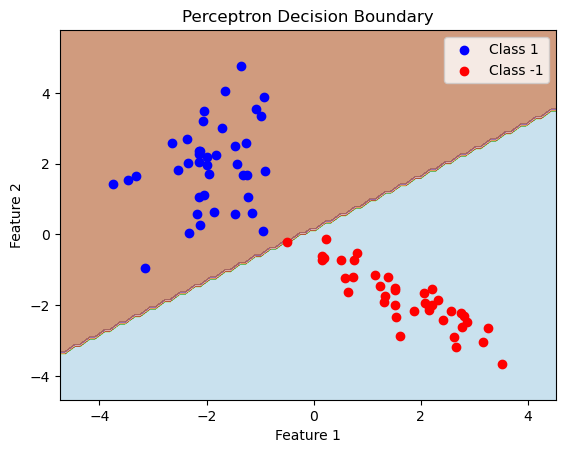

In [6]:


X, y = make_classification(
    n_samples=100,      
    n_features=2,       
    n_informative=2,   
    n_redundant=0,      
    n_clusters_per_class=1,
    flip_y=0,           
    class_sep=2.0,      
)


y = np.where(y == 0, -1, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


perceptron = Perceptron(learning_rate=0.01, max_iter=1000)


perceptron.fit(X_train, y_train)


y_train_pred = perceptron.predict(X_train)
y_test_pred = perceptron.predict(X_test)


train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)


print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

import matplotlib.pyplot as plt
import numpy as np


def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))


    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_predictions = model.step(model.predict(grid_points)).reshape(xx.shape)


    plt.contourf(xx, yy, grid_predictions, alpha=0.6, cmap=plt.cm.Paired)


    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1')
    plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.title('Perceptron Decision Boundary')
    plt.show()


plot_decision_boundary(X_train, y_train, perceptron)
